# E-commerce Customer and Demand Analytics

## Business Context
This project analyses transactional e-commerce data to understand customer behaviour, category performance, and short-term demand patterns. The goal is to generate insights that support commercial decisions, customer strategy, and demand planning.

## Objectives
- Build a clean order-level and item-level dataset from multiple source tables
- Analyse customer and category behaviour using core commercial KPIs
- Conduct a simple pre/post performance comparison
- Develop a short-term demand forecast and review forecast accuracy
- Translate findings into practical business recommendations

## 1. Load Libraries and Data
We first import the required libraries and load the source datasets used in this analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [12]:
orders = pd.read_csv('/content/olist_orders_dataset.csv')
order_items = pd.read_csv('/content/olist_order_items_dataset.csv')
payments = pd.read_csv('/content/olist_order_payments_dataset.csv')
products = pd.read_csv('/content/olist_products_dataset.csv')
customers = pd.read_csv('/content/olist_customers_dataset.csv')
cat_trans = pd.read_csv('/content/product_category_name_translation.csv')

## 2. Initial Data Understanding
Before merging tables, we inspect the structure, column names, and missing values in each dataset.

In [22]:
tables = {
    "orders": orders,
    "order_items": order_items,
    "payments": payments,
    "products": products,
    "customers": customers,
    "cat_trans": cat_trans
}

for name, df in tables.items():
    print(f"\n=== {name.upper()} ===")
    print("Shape:", df.shape)
    print("\nColumns:")
    print(df.columns.tolist())
    print("\nMissing values (top 10):")
    print(df.isna().sum().sort_values(ascending=False).head(10))
    print("\nSample:")
    display(df.head(3))


=== ORDERS ===
Shape: (99441, 8)

Columns:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

Missing values (top 10):
order_delivered_customer_date    2965
order_delivered_carrier_date     1783
order_approved_at                 160
order_id                            0
order_purchase_timestamp            0
order_status                        0
customer_id                         0
order_estimated_delivery_date       0
dtype: int64

Sample:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04



=== ORDER_ITEMS ===
Shape: (112650, 7)

Columns:
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

Missing values (top 10):
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

Sample:


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.0,17.87



=== PAYMENTS ===
Shape: (103886, 5)

Columns:
['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']

Missing values (top 10):
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

Sample:


...

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0



=== CUSTOMERS ===
Shape: (99441, 5)

Columns:
['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

Missing values (top 10):
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Sample:


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP



=== CAT_TRANS ===
Shape: (71, 2)

Columns:
['product_category_name', 'product_category_name_english']

Missing values (top 10):
product_category_name            0
product_category_name_english    0
dtype: int64

Sample:


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto


## 3. Prepare Core Date Fields and Filter Relevant Orders
The orders table contains multiple operational timestamps. These are converted into datetime format, and the analysis is restricted to delivered orders to ensure commercial metrics are based on completed transactions.

In [18]:
date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col], errors="coerce")

orders["order_status"].value_counts(dropna=False)

,count
order_status,
delivered,96478
shipped,1107
canceled,625
unavailable,609
invoiced,314
processing,301
created,5
approved,2


In [19]:
orders_delivered = orders[orders["order_status"] == "delivered"].copy()
print("Delivered orders shape:", orders_delivered.shape)

Delivered orders shape: (96478, 8)


## 4. Aggregate Payments and Items to Order Level
Some source tables contain multiple rows per order. To avoid double counting during merges, payment and item information is aggregated to the order level first.

In [20]:
payment_by_order = (
    payments.groupby("order_id", as_index=False)
    .agg(
        payment_value_total=("payment_value", "sum"),
        payment_installments_max=("payment_installments", "max"),
        payment_sequential_count=("payment_sequential", "count")
    )
)

payment_by_order.head()

,order_id,payment_value_total,payment_installments_max,payment_sequential_count
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,2,1
1,00018f77f2f0320c557190d7a144bdd3,259.83,3,1
2,000229ec398224ef6ca0657da4fc703e,216.87,5,1
3,00024acbcdf0a6daa1e931b038114c75,25.78,2,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,3,1


In [23]:
items_by_order = (
    order_items.groupby("order_id", as_index=False)
    .agg(
        item_count=("order_item_id", "count"),
        item_price_total=("price", "sum"),
        freight_total=("freight_value", "sum")
    )
)

items_by_order.head()

,order_id,item_count,item_price_total,freight_total
0,00010242fe8c5a6d1ba2dd792cb16214,1,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,199.90,18.14


## 5. Build an Order-Level Dataset
An order-level dataset is created by merging delivered orders with customer, payment, and item summaries. This dataset is used for KPI reporting, customer analysis, pre/post comparison, and forecasting.

In [24]:
order_level = (
    orders_delivered
    .merge(customers, on="customer_id", how="left")
    .merge(payment_by_order, on="order_id", how="left")
    .merge(items_by_order, on="order_id", how="left")
)

print(order_level.shape)
order_level.head()

(96478, 18)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,payment_value_total,payment_installments_max,payment_sequential_count,item_count,item_price_total,freight_total
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,38.71,1.0,3.0,1,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,141.46,1.0,1.0,1,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,179.12,3.0,1.0,1,159.90,19.22
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,72.20,1.0,1.0,1,45.00,27.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,28.62,1.0,1.0,1,19.90,8.72


In [25]:
order_level["order_date"] = order_level["order_purchase_timestamp"].dt.date
order_level["order_month"] = order_level["order_purchase_timestamp"].dt.to_period("M").astype(str)
order_level["order_week"] = order_level["order_purchase_timestamp"].dt.to_period("W").astype(str)
order_level["order_year_month"] = order_level["order_purchase_timestamp"].dt.to_period("M")
order_level["order_value"] = order_level["payment_value_total"]

## 6. Create Customer Behaviour Features
Customer behaviour is analysed using the customer_unique_id field, which identifies the same customer across multiple orders. This allows repeat purchase patterns to be measured more accurately.

In [26]:
customer_order_counts = (
    order_level.groupby("customer_unique_id", as_index=False)
    .agg(total_orders=("order_id", "nunique"))
)

order_level = order_level.merge(customer_order_counts, on="customer_unique_id", how="left")

order_level["customer_type"] = np.where(order_level["total_orders"] > 1, "Repeat", "One-time")

In [27]:
first_purchase = (
    order_level.groupby("customer_unique_id", as_index=False)
    .agg(first_purchase_ts=("order_purchase_timestamp", "min"))
)

order_level = order_level.merge(first_purchase, on="customer_unique_id", how="left")
order_level["first_purchase_month"] = order_level["first_purchase_ts"].dt.to_period("M").astype(str)

## 7. Build an Order-Item-Level Dataset
An item-level dataset is created to analyse product category performance. Product category labels are also translated into English to improve readability in outputs.

In [28]:
products = products.merge(
    cat_trans,
    on="product_category_name",
    how="left"
)

order_item_level = (
    order_items
    .merge(
        products[["product_id", "product_category_name", "product_category_name_english"]],
        on="product_id",
        how="left"
    )
    .merge(
        orders_delivered[["order_id", "customer_id", "order_purchase_timestamp"]],
        on="order_id",
        how="inner"
    )
    .merge(
        customers[["customer_id", "customer_unique_id"]],
        on="customer_id",
        how="left"
    )
)

order_item_level["order_month"] = order_item_level["order_purchase_timestamp"].dt.to_period("M").astype(str)
order_item_level["order_week"] = order_item_level["order_purchase_timestamp"].dt.to_period("W").astype(str)
order_item_level["item_revenue"] = order_item_level["price"] + order_item_level["freight_value"]

print(order_item_level.shape)
order_item_level.head()

(110197, 15)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_category_name_english,customer_id,order_purchase_timestamp,customer_unique_id,order_month,order_week,item_revenue
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,cool_stuff,3ce436f183e68e07877b285a838db11a,2017-09-13 08:59:02,871766c5855e863f6eccc05f988b23cb,2017-09,2017-09-11/2017-09-17,72.19
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,pet_shop,f6dd3ec061db4e3987629fe6b26e5cce,2017-04-26 10:53:06,eb28e67c4c0b83846050ddfb8a35d051,2017-04,2017-04-24/2017-04-30,259.83
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,furniture_decor,6489ae5e4333f3693df5ad4372dab6d3,2018-01-14 14:33:31,3818d81c6709e39d06b2738a8d3a2474,2018-01,2018-01-08/2018-01-14,216.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,perfumery,d4eb9395c8c0431ee92fce09860c5a06,2018-08-08 10:00:35,af861d436cfc08b2c2ddefd0ba074622,2018-08,2018-08-06/2018-08-12,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,garden_tools,58dbd0b2d70206bf40e62cd34e84d795,2017-02-04 13:57:51,64b576fb70d441e8f1b2d7d446e483c5,2017-02,2017-01-30/2017-02-05,218.04


## 8. Quick Data Quality Checks
Basic checks are performed to confirm the merged datasets are usable for analysis and to identify any remaining data issues.

In [29]:
print("Order-level shape:", order_level.shape)
print("Order-item-level shape:", order_item_level.shape)

print("Duplicate order_id in order_level:", order_level["order_id"].duplicated().sum())
print("Missing order_value ratio:", order_level["order_value"].isna().mean())
print("Missing English category ratio:", order_item_level["product_category_name_english"].isna().mean())

Order-level shape: (96478, 27)
Order-item-level shape: (110197, 15)
Duplicate order_id in order_level: 0
Missing order_value ratio: 1.0365057318766973e-05
Missing English category ratio: 0.014147390582320753


## 9. KPI Overview
The following high-level commercial KPIs are calculated to summarise business performance.

In [30]:
total_orders = order_level["order_id"].nunique()
total_revenue = order_level["order_value"].sum()
aov = order_level["order_value"].mean()
repeat_rate = (order_level["customer_type"] == "Repeat").mean()

print("Total orders:", total_orders)
print("Total revenue:", round(total_revenue, 2))
print("Average order value:", round(aov, 2))
print("Repeat customer rate:", round(repeat_rate, 4))

Total orders: 96478
Total revenue: 15422461.77
Average order value: 159.86
Repeat customer rate: 0.0614




- The dataset captures a meaningful level of commercial activity, with over 96,000 delivered orders and total order value above 15 million.
- Average order value is relatively stable at an aggregate level, suggesting that overall revenue growth is likely to be driven more by changes in order volume than by large movements in basket size.
- The repeat customer rate is low at approximately 6%, which suggests the business may rely heavily on one-time purchases. However, this should be interpreted cautiously, as repeat behaviour may also be influenced by the available observation window and category purchasing cycles.

## 10. Revenue Trend Over Time
Monthly revenue and order volume are examined to understand overall business growth and fluctuations over time.

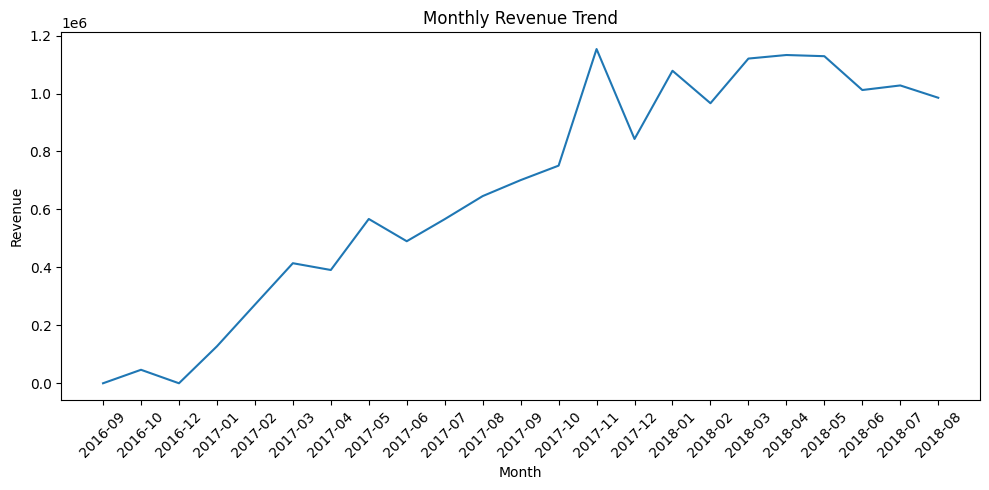

In [31]:
monthly_trend = (
    order_level.groupby("order_year_month", as_index=False)
    .agg(
        orders=("order_id", "nunique"),
        revenue=("order_value", "sum")
    )
    .sort_values("order_year_month")
)

monthly_trend["order_year_month_str"] = monthly_trend["order_year_month"].astype(str)

plt.figure(figsize=(10, 5))
plt.plot(monthly_trend["order_year_month_str"], monthly_trend["revenue"])
plt.xticks(rotation=45)
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()



- Monthly revenue and order volume both show a clear upward trend over time, indicating overall business growth during the observed period.
- The growth pattern is not perfectly smooth, with several fluctuations and spikes that may reflect seasonality, campaigns, assortment changes, or operational factors.
- Because growth appears to be driven by volume as well as timing effects, short-term performance should be interpreted with both trend and business context in mind.

## 11. Top Product Categories
Category-level performance is analysed to identify the strongest contributors to revenue and order volume.

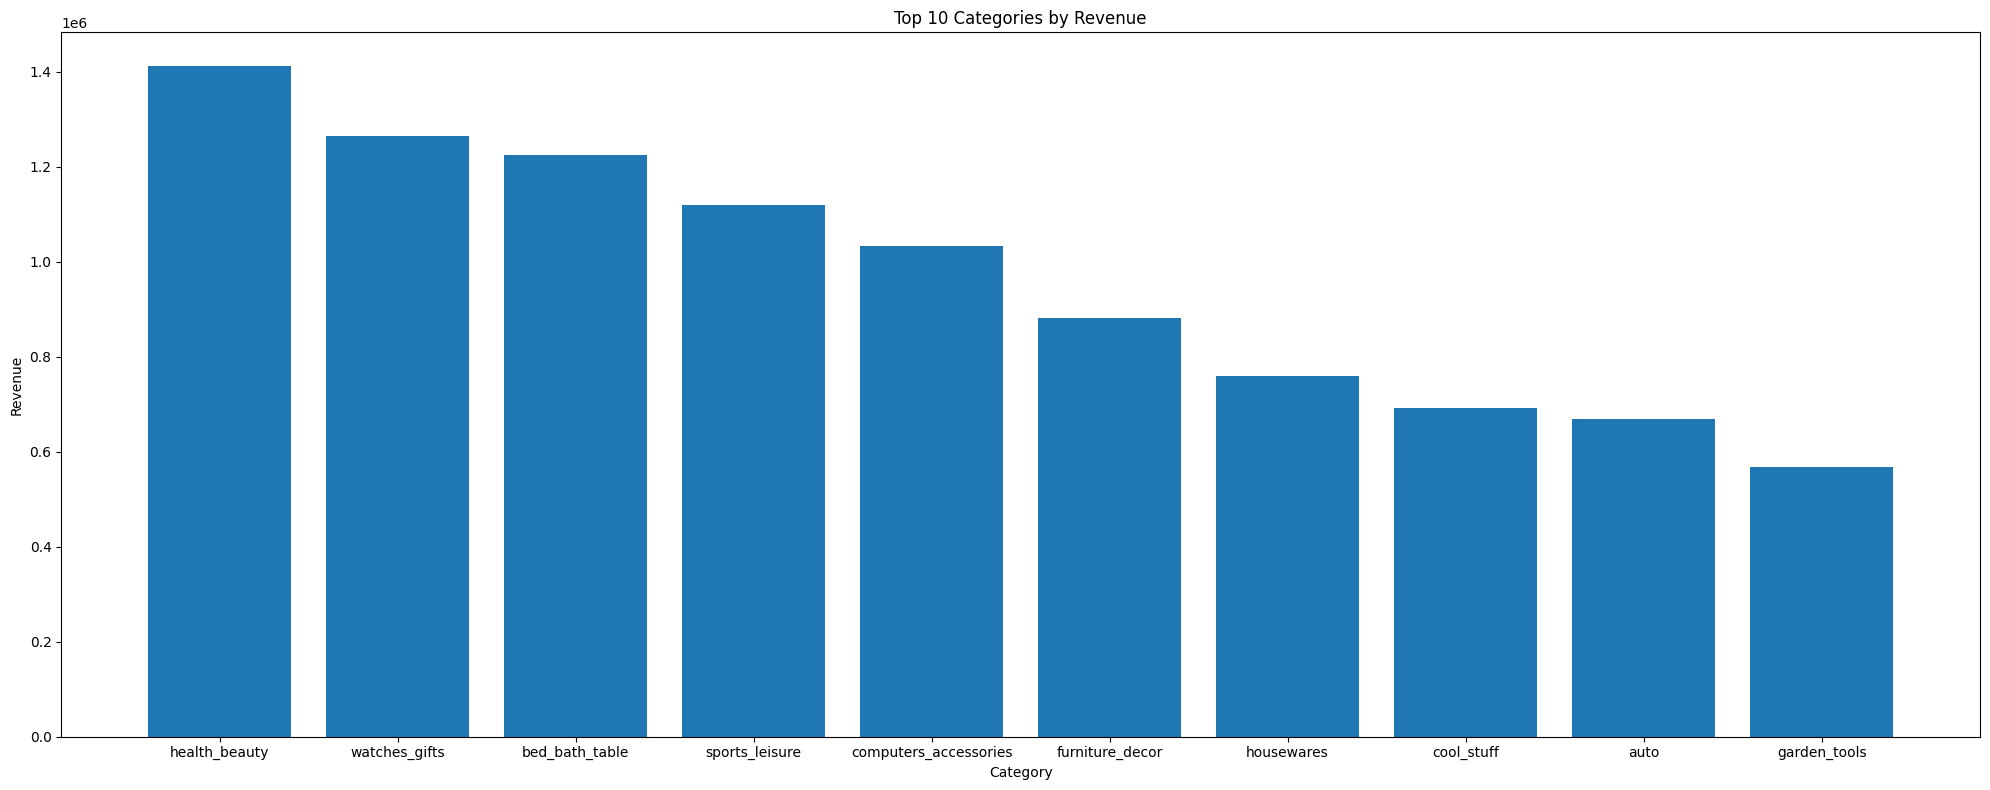

,product_category_name_english,orders,revenue
43,health_beauty,8647,1412089.53
70,watches_gifts,5495,1264333.12
7,bed_bath_table,9272,1225209.26
65,sports_leisure,7530,1118256.91
15,computers_accessories,6530,1032723.77
39,furniture_decor,6307,880329.92
49,housewares,5743,758392.25
20,cool_stuff,3559,691680.89
5,auto,3810,669454.75
42,garden_tools,3448,567145.68


In [37]:
top_categories = (
    order_item_level.groupby("product_category_name_english", as_index=False)
    .agg(
        orders=("order_id", "nunique"),
        revenue=("item_revenue", "sum")
    )
    .sort_values("revenue", ascending=False)
    .head(10)
)

plt.figure(figsize=(20, 8))
plt.bar(top_categories["product_category_name_english"], top_categories["revenue"])
plt.xticks(rotation=0)
plt.title("Top 10 Categories by Revenue")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

top_categories



- Revenue appears concentrated in a relatively small number of product categories, including health and beauty, watches and gifts, and bed, bath, and table.
- This concentration suggests the business has identifiable category leaders that likely play a disproportionate role in total commercial performance.
- While category concentration can support focused commercial strategy, it also introduces risk if demand weakens in a small number of core categories. Category-level monitoring is therefore important for both growth and resilience.

## 12. Repeat vs One-Time Customer Behaviour
Customers are segmented into repeat and one-time groups to compare their contribution to revenue and orders.

In [38]:
segment_summary = (
    order_level.groupby("customer_type", as_index=False)
    .agg(
        customers=("customer_unique_id", "nunique"),
        orders=("order_id", "nunique"),
        revenue=("order_value", "sum"),
        aov=("order_value", "mean")
    )
)

segment_summary

,customer_type,customers,orders,revenue,aov
0,One-time,90557,90557,14558104.56,160.763556
1,Repeat,2801,5921,864357.21,145.981626


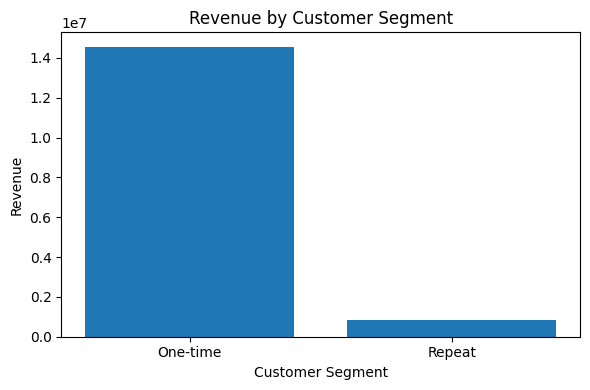

In [39]:
plt.figure(figsize=(6, 4))
plt.bar(segment_summary["customer_type"], segment_summary["revenue"])
plt.title("Revenue by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()



- One-time customers account for the overwhelming majority of customers and orders in the dataset, while repeat customers contribute a much smaller share of business activity.
- This indicates that the business may currently depend more on acquisition and first-time conversion than on sustained repeat purchasing behaviour.
- Repeat customer value should not be judged using headline counts alone. A more useful next step would be to examine repeat behaviour by product category, customer value tier, or first-purchase cohort to identify where retention opportunities are strongest.

## 13. Pre/Post Comparison
A simple observational pre/post comparison is conducted around a selected point in time to evaluate directional changes in business performance.

This is not a randomized experiment, so the results should be interpreted as indicative rather than causal.

In [40]:
monthly_trend[["order_year_month_str", "orders", "revenue"]]

,order_year_month_str,orders,revenue
0,2016-09,1,0.00
1,2016-10,265,46566.71
2,2016-12,1,19.62
3,2017-01,750,127545.67
4,2017-02,1653,271298.65
5,2017-03,2546,414369.39
6,2017-04,2303,390952.18
7,2017-05,3546,567066.73
8,2017-06,3135,490225.60
9,2017-07,3872,566403.93


In [41]:
cutoff_month = "2017-11"

pre_post = (
    order_level.assign(period=np.where(order_level["order_month"] < cutoff_month, "Before", "After"))
    .groupby("period", as_index=False)
    .agg(
        orders=("order_id", "nunique"),
        revenue=("order_value", "sum"),
        avg_order_value=("order_value", "mean"),
        repeat_order_share=("customer_type", lambda x: (x == "Repeat").mean())
    )
)

pre_post

,period,orders,revenue,avg_order_value,repeat_order_share
0,After,65585,10449702.42,159.330677,0.055226
1,Before,30893,4972759.35,160.972399,0.074418




- The post-cutoff period shows materially higher order volume and revenue than the earlier period, indicating that the business expanded significantly over time.
- Average order value changed less dramatically than total orders and revenue, which suggests that growth was driven more by increased transaction volume than by a major increase in spend per order.
- Repeat order share appears lower in the later period, which may indicate that growth was supported more by customer acquisition or broader demand expansion than by stronger repeat purchasing.
- This comparison is directional only and should be treated as an exploratory performance shift analysis rather than evidence of a causal business intervention.

## 14. Weekly Demand for Forecasting
Weekly order volume is used as the target series for short-term forecasting, as weekly aggregation reduces day-to-day noise and produces a more stable series for business planning.

In [42]:
weekly_demand = (
    order_level.set_index("order_purchase_timestamp")
    .resample("W")
    .agg(
        orders=("order_id", "nunique"),
        revenue=("order_value", "sum")
    )
    .reset_index()
)

weekly_demand.head()

,order_purchase_timestamp,orders,revenue
0,2016-09-18,1,0.00
1,2016-09-25,0,0.00
2,2016-10-02,0,0.00
3,2016-10-09,231,42669.98
4,2016-10-16,34,3896.73


## 15. Short-Term Forecasting
A simple exponential smoothing model is fitted to weekly order volume. Forecast performance is evaluated on a holdout period using MAE and MAPE.

In [59]:
ts = weekly_demand[["order_purchase_timestamp", "orders"]].dropna().copy()
ts = ts.set_index("order_purchase_timestamp")

train = ts.iloc[:-8]
test = ts.iloc[-8:]

model_results = []

configs = [
    {"name": "Trend only", "trend": "add", "seasonal": None, "seasonal_periods": None},
    {"name": "Trend + Seasonality (4)", "trend": "add", "seasonal": "add", "seasonal_periods": 4},
    {"name": "Trend + Seasonality (8)", "trend": "add", "seasonal": "add", "seasonal_periods": 8},
    {"name": "Trend + Seasonality (12)", "trend": "add", "seasonal": "add", "seasonal_periods": 12},
]

best_model = None
best_pred = None
best_name = None
best_mape = float("inf")

for cfg in configs:
    try:
        model = ExponentialSmoothing(
            train["orders"],
            trend=cfg["trend"],
            seasonal=cfg["seasonal"],
            seasonal_periods=cfg["seasonal_periods"]
        ).fit(optimized=True)

        pred = model.forecast(len(test))

        mae = mean_absolute_error(test["orders"], pred)
        mape = mean_absolute_percentage_error(test["orders"], pred)

        model_results.append({
            "model": cfg["name"],
            "MAE": mae,
            "MAPE": mape
        })

        if mape < best_mape:
            best_mape = mape
            best_model = model
            best_pred = pred
            best_name = cfg["name"]

    except Exception as e:
        model_results.append({
            "model": cfg["name"],
            "MAE": np.nan,
            "MAPE": np.nan
        })

results_df = pd.DataFrame(model_results).sort_values("MAPE")
results_df

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)


,model,MAE,MAPE
3,Trend + Seasonality (12),217.015659,0.168687
0,Trend only,278.957866,0.195136
1,Trend + Seasonality (4),280.605942,0.200245
2,Trend + Seasonality (8),339.980191,0.237198


In [60]:
forecast_results = test.copy()
forecast_results["forecast_orders"] = pred.values
forecast_results["abs_error"] = (forecast_results["orders"] - forecast_results["forecast_orders"]).abs()

forecast_results

,orders,forecast_orders,abs_error
order_purchase_timestamp,,,
2018-07-01,1382,1571.195437,189.195437
2018-07-08,1178,1529.528168,351.528168
2018-07-15,972,1527.521061,555.521061
2018-07-22,1649,1577.242434,71.757566
2018-07-29,1610,1595.192520,14.807480
2018-08-05,2002,1857.672018,144.327982
2018-08-12,1931,1755.822936,175.177064
2018-08-19,1839,1605.189483,233.810517


Best model: Trend + Seasonality (12)
Best MAE: 217.02
Best MAPE: 0.1687


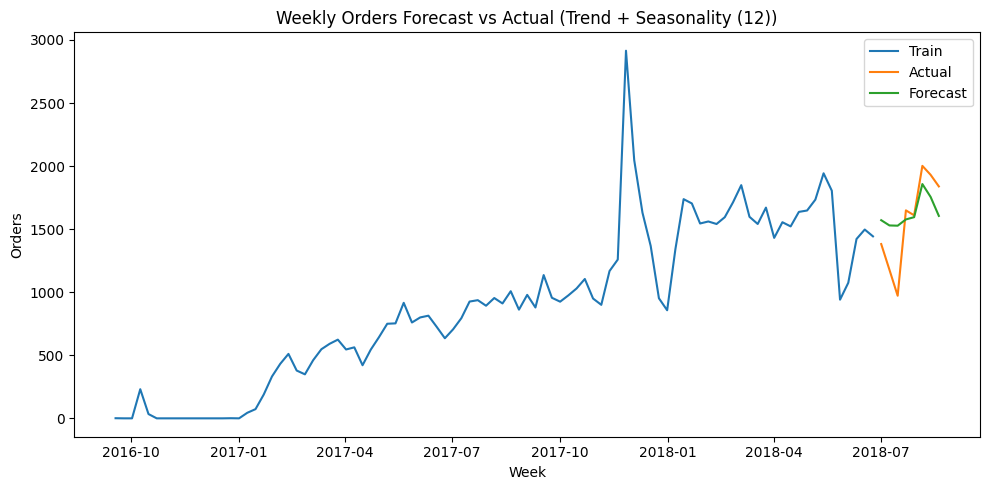

In [61]:
forecast_results = test.copy()
forecast_results["forecast_orders"] = best_pred.values
forecast_results["abs_error"] = (forecast_results["orders"] - forecast_results["forecast_orders"]).abs()

print("Best model:", best_name)
print("Best MAE:", round(mean_absolute_error(test["orders"], best_pred), 2))
print("Best MAPE:", round(mean_absolute_percentage_error(test["orders"], best_pred), 4))

plt.figure(figsize=(10, 5))
plt.plot(train.index, train["orders"], label="Train")
plt.plot(test.index, test["orders"], label="Actual")
plt.plot(test.index, forecast_results["forecast_orders"], label="Forecast")
plt.legend()
plt.title(f"Weekly Orders Forecast vs Actual ({best_name})")
plt.xlabel("Week")
plt.ylabel("Orders")
plt.tight_layout()
plt.show()


- Weekly orders show both a strong upward trend and noticeable short-term volatility.
- The seasonal model provides a more realistic forecast profile than a simple trend-only baseline and captures the overall demand level reasonably well.
- However, some forecast gaps remain in weeks with sharper demand swings, suggesting that weekly performance is influenced by business factors beyond trend and seasonality alone.
- This means the forecast is useful as a short-term planning baseline, but should be combined with business context and exception review.

## 16. Forecast Exception Review
Forecast errors are reviewed to identify weeks where actual demand deviated most strongly from expected levels.

In [62]:
largest_errors = forecast_results.sort_values("abs_error", ascending=False).head(5)
largest_errors

,orders,forecast_orders,abs_error
order_purchase_timestamp,,,
2018-07-15,972,1527.521061,555.521061
2018-07-08,1178,1529.528168,351.528168
2018-08-19,1839,1605.189483,233.810517
2018-07-01,1382,1571.195437,189.195437
2018-08-12,1931,1755.822936,175.177064




- The largest forecast errors occur in a limited number of weeks, rather than being evenly distributed across the holdout period.
- This pattern suggests that forecast misses may be linked to business-specific exceptions or temporary demand shocks rather than to a complete failure of the underlying forecasting approach.
- In practice, these high-error weeks should be reviewed alongside commercial and operational context to determine whether they reflect promotional activity, external events, reporting issues, or genuine shifts in customer demand.

## Business Recommendations

### 1. Focus retention efforts more selectively
The low repeat purchase share suggests that the business may depend heavily on one-time transactions. Rather than applying broad retention tactics uniformly, the company should identify categories, customer segments, or first-purchase cohorts with stronger repeat potential and prioritise retention efforts in those areas.

### 2. Monitor category concentration more closely
A relatively small number of product categories contribute a large share of total revenue. These categories should be monitored as core commercial drivers, while management should also track concentration risk and identify opportunities to diversify category performance where appropriate.

### 3. Use short-term forecasts as a planning baseline, not a standalone decision tool
The seasonal forecasting model provides a useful baseline for short-term demand planning, but forecast misses in several weeks indicate that statistical output alone is not sufficient. Forecasts should be reviewed alongside promotional calendars, category dynamics, and operational context before planning decisions are finalised.

### 4. Introduce exception-based reporting into weekly demand reviews
Weeks with unusually large forecast errors should trigger a structured review process rather than being treated as ordinary variation. This would improve planning discipline and help the business distinguish between normal volatility and meaningful demand shifts requiring action.

## Limitations

- This analysis is based on observational transaction data and does not establish causal relationships with certainty.
- The pre/post comparison is intended as a directional business performance check, not as a randomized experiment or formal impact evaluation.
- Repeat purchase behaviour is approximated using the available order history and may not fully capture long-term customer lifetime behaviour.
- Forecast accuracy is constrained by short-term volatility and by the absence of additional explanatory variables such as promotions, seasonality markers, or external demand drivers.